<a href="https://colab.research.google.com/github/Varsh999/dllab/blob/main/mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 28ms/step - accuracy: 0.9559 - loss: 0.1427 - val_accuracy: 0.9846 - val_loss: 0.0525
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9853 - loss: 0.0469 - val_accuracy: 0.9879 - val_loss: 0.0359
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.9903 - loss: 0.0317 - val_accuracy: 0.9898 - val_loss: 0.0325
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 27ms/step - accuracy: 0.9919 - loss: 0.0244 - val_accuracy: 0.9907 - val_loss: 0.0300
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 27ms/step - accuracy: 0.9940 - loss: 0.0186 - val_accuracy: 0.9900 - val_loss: 0.0350
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9900 - loss: 0.0350

Test Accuracy: 0.9900000095367432
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

Predicted label: 7
Actual label: 7


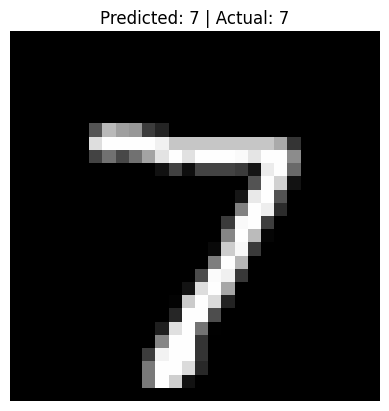

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load MNIST Dataset
# -----------------------------
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# -----------------------------
# 2. Preprocess Data
# -----------------------------
# Normalize (0 to 1)
train_images = train_images / 255.0
test_images = test_images / 255.0

# Reshape to (28, 28, 1) for CNN
train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))

# -----------------------------
# 3. Build CNN Model
# -----------------------------
model = models.Sequential()

# 🔹 Convolution + Pooling Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

# 🔹 Convolution + Pooling Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# 🔹 Flatten + Dense Layers
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))  # 10 classes (0–9)

# -----------------------------
# 4. Compile Model
# -----------------------------
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# -----------------------------
# 5. Train Model
# -----------------------------
history = model.fit(train_images, train_labels,
                    epochs=5,
                    validation_data=(test_images, test_labels))

# -----------------------------
# 6. Evaluate Model
# -----------------------------
test_loss, test_acc = model.evaluate(test_images, test_labels)

print("\nTest Accuracy:", test_acc)

# -----------------------------
# 7. Predict Sample
# -----------------------------
predictions = model.predict(test_images)

print("\nPredicted label:", predictions[0].argmax())
print("Actual label:", test_labels[0])
import matplotlib.pyplot as plt

# Show first test image
plt.imshow(test_images[0].reshape(28, 28), cmap='gray')

plt.title(f"Predicted: {predictions[0].argmax()} | Actual: {test_labels[0]}")
plt.axis('off')

plt.show()